In [13]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from math import pi

In [2]:
# Set style
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.2)

BASE_DIR = "results"
models = ["GCN", "GAT", "SAGE"]

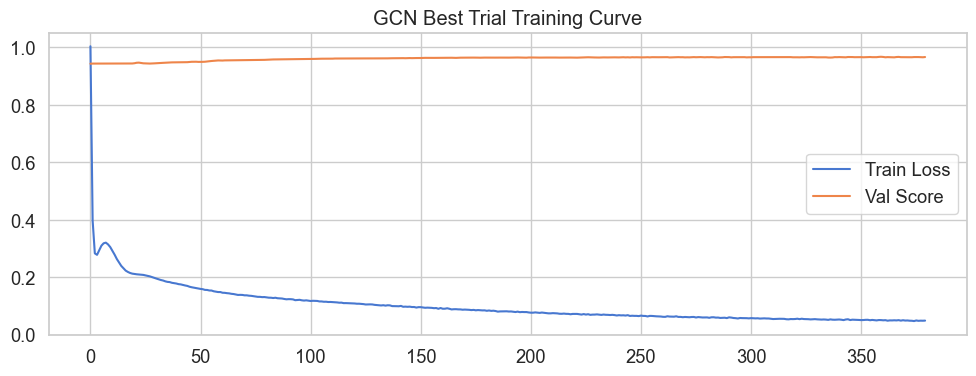

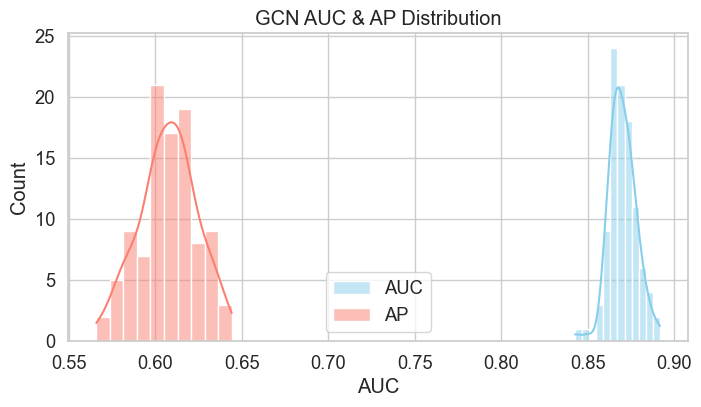

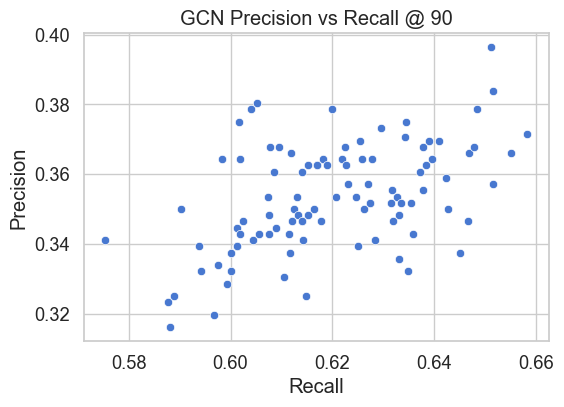

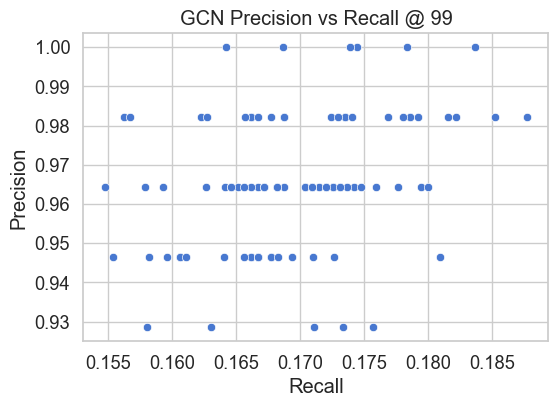

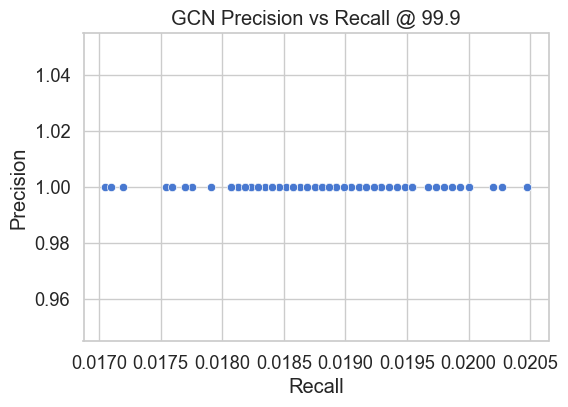

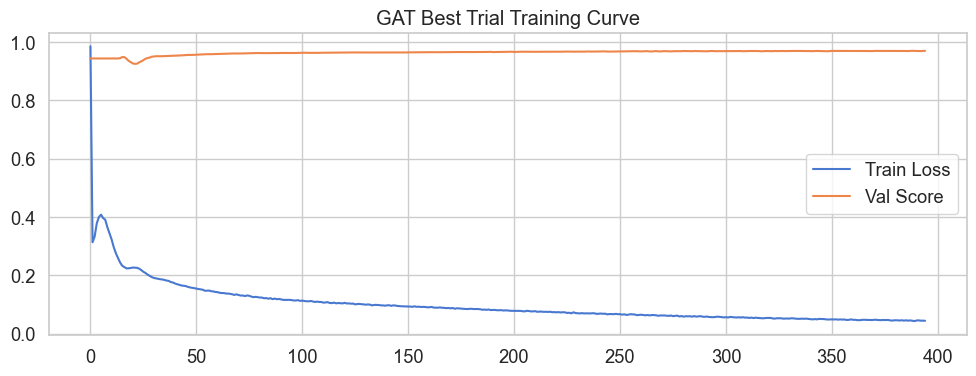

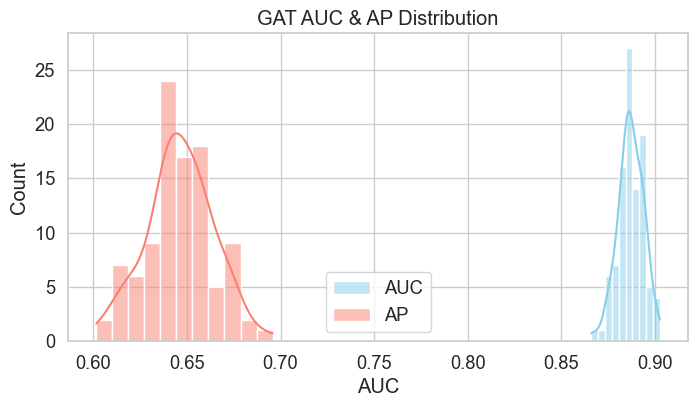

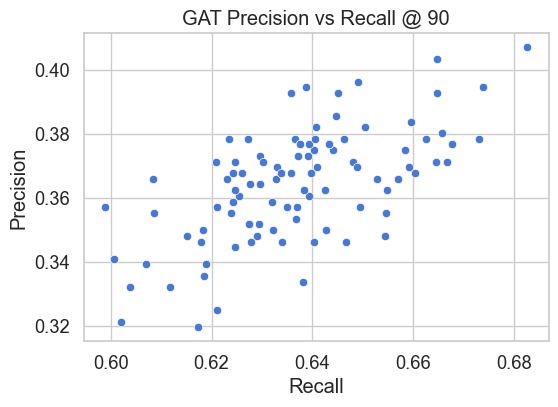

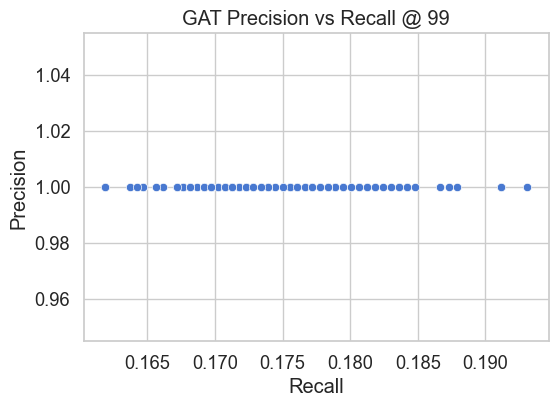

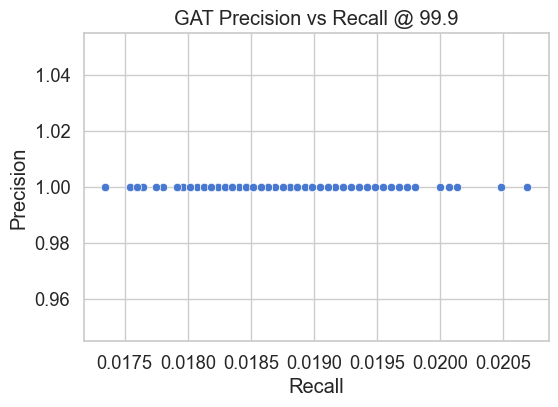

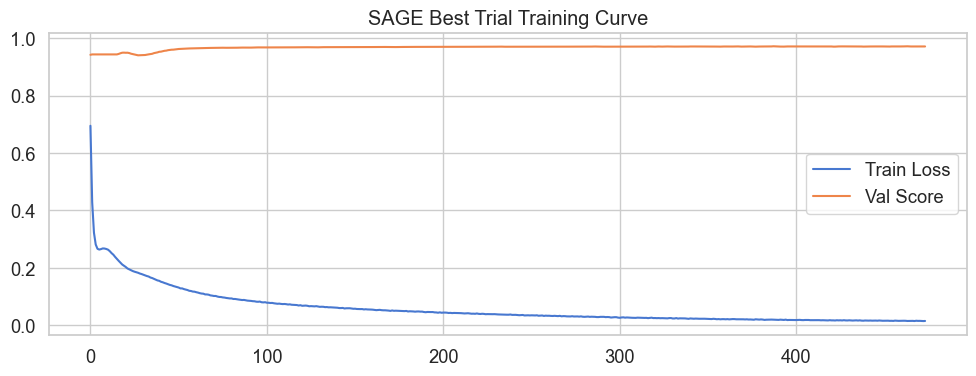

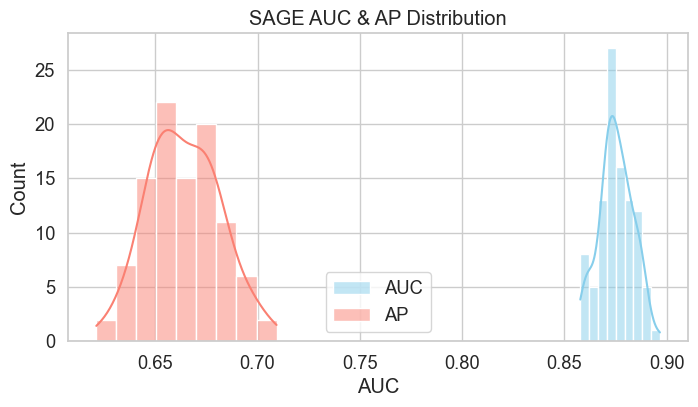

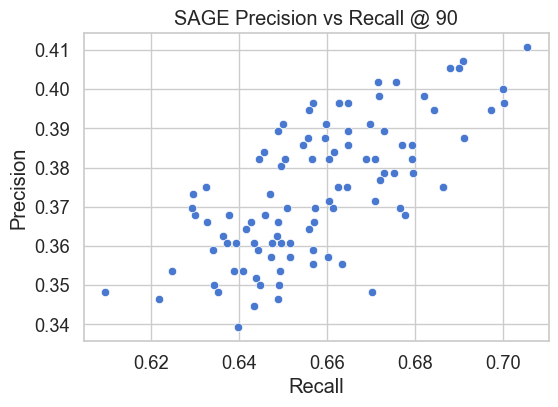

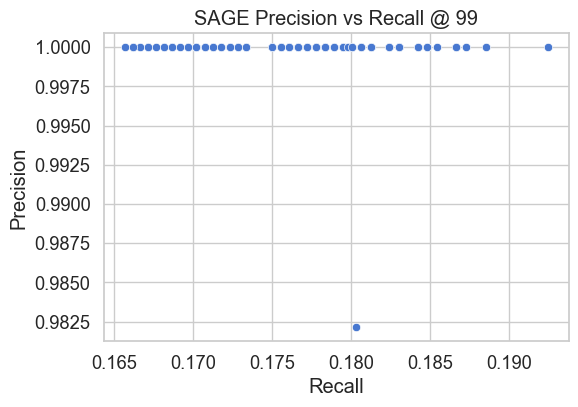

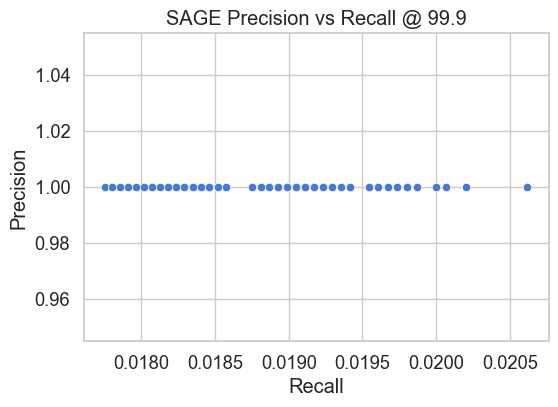

In [3]:
summary_metrics = []

for model in models:
    # Load training results
    with open(os.path.join(BASE_DIR, model, f"{model}_training_results.json")) as f:
        train_results = json.load(f)
    
    auc_prc = train_results.get("AUC_PRC")
    params = train_results.get("Parameters", {})
    study = pd.DataFrame(train_results.get("Study", []))
    
    # Load TD & TI
    td = pd.read_csv(os.path.join(BASE_DIR, model, "results_TD.csv"))
    ti = pd.read_csv(os.path.join(BASE_DIR, model, "results_TI.csv"))
    
    # Store summary
    summary_metrics.append({
        "Model": model,
        "AUC_PRC": auc_prc,
        "Mean_AUC": ti["AUC"].mean(),
        "Mean_AP": ti["AP"].mean(),
        "F1@90": td["F1_Score_90"].mean(),
        "F1@99": td["F1_Score_99"].mean(),
        "F1@99.9": td["F1_Score_99.9"].mean()
    })
    
    # === Plot training curves (best trial) ===
    best_trial = max(train_results["Study"], key=lambda x: x["value"])
    history = best_trial["user_attrs_history"]
    plt.figure(figsize=(10,4))
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_score"], label="Val Score")
    plt.title(f"{model} Best Trial Training Curve")
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # === Plot distributions of test metrics ===
    plt.figure(figsize=(8,4))
    sns.histplot(ti["AUC"], kde=True, label="AUC", color="skyblue")
    sns.histplot(ti["AP"], kde=True, label="AP", color="salmon")
    plt.title(f"{model} AUC & AP Distribution")
    plt.legend()
    plt.show()
    
    # === Precision-Recall tradeoff ===
    thresholds = ["90","99","99.9"]
    for t in thresholds:
        plt.figure(figsize=(6,4))
        sns.scatterplot(x=td[f"Recall_{t}"], y=td[f"Precision_{t}"])
        plt.title(f"{model} Precision vs Recall @ {t}")
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.show()

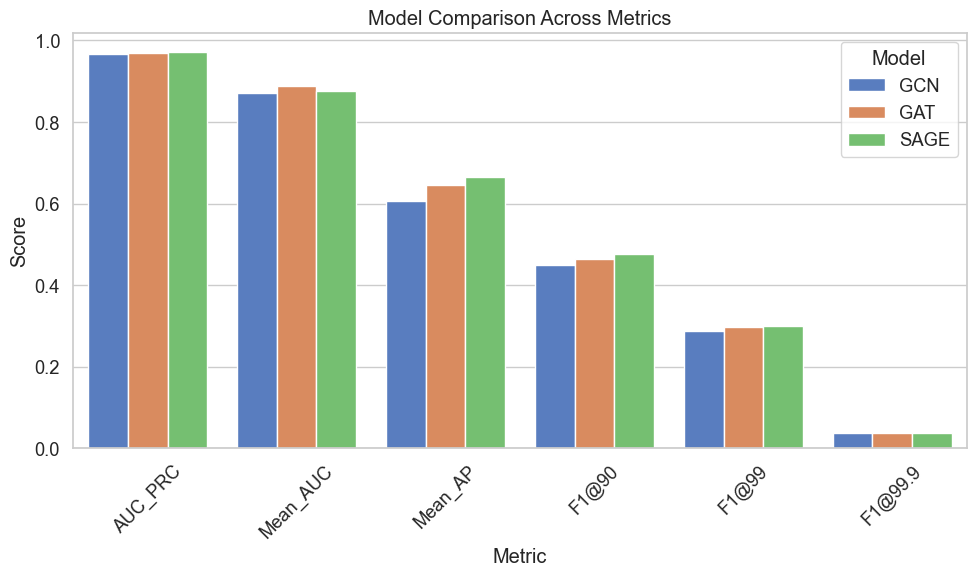

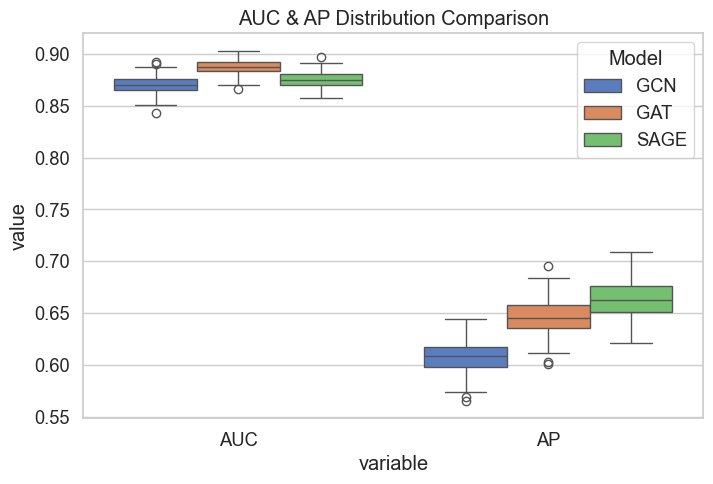

In [4]:
# === Compare summary across models ===
summary_df = pd.DataFrame(summary_metrics)

plt.figure(figsize=(10,6))
summary_df_melt = summary_df.melt("Model", var_name="Metric", value_name="Score")
sns.barplot(data=summary_df_melt, x="Metric", y="Score", hue="Model")
plt.title("Model Comparison Across Metrics")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# === Boxplot AUC/AP comparison ===
plt.figure(figsize=(8,5))
all_ti = []
for model in models:
    df = pd.read_csv(os.path.join(BASE_DIR, model, "results_TI.csv"))
    df["Model"] = model
    all_ti.append(df)
all_ti = pd.concat(all_ti)
sns.boxplot(data=all_ti.melt(id_vars="Model"), x="variable", y="value", hue="Model")
plt.title("AUC & AP Distribution Comparison")
plt.show()

In [5]:
summary_metrics = []
all_td = []
all_ti = []
all_histories = []

# === Load everything ===
for model in models:
    with open(os.path.join(BASE_DIR, model, f"{model}_training_results.json")) as f:
        train_results = json.load(f)

    auc_prc = train_results.get("AUC_PRC")
    params = train_results.get("Parameters", {})
    
    # Trials
    study = pd.DataFrame(train_results.get("Study", []))
    
    # CSVs
    td = pd.read_csv(os.path.join(BASE_DIR, model, "results_TD.csv"))
    ti = pd.read_csv(os.path.join(BASE_DIR, model, "results_TI.csv"))
    td["Model"] = model
    ti["Model"] = model
    all_td.append(td)
    all_ti.append(ti)

    # Summary
    summary_metrics.append({
        "Model": model,
        "AUC_PRC": auc_prc,
        "Mean_AUC": ti["AUC"].mean(),
        "Mean_AP": ti["AP"].mean(),
        "F1@90": td["F1_Score_90"].mean(),
        "F1@99": td["F1_Score_99"].mean(),
        "F1@99.9": td["F1_Score_99.9"].mean()
    })

    # Training history of best trial
    best_trial = max(train_results["Study"], key=lambda x: x["value"])
    history = best_trial["user_attrs_history"]
    all_histories.append(pd.DataFrame({
        "epoch": range(len(history["train_loss"])),
        "train_loss": history["train_loss"],
        "val_score": history["val_score"],
        "Model": model
    }))

summary_df = pd.DataFrame(summary_metrics)
all_td = pd.concat(all_td, ignore_index=True)
all_ti = pd.concat(all_ti, ignore_index=True)
all_histories = pd.concat(all_histories, ignore_index=True)

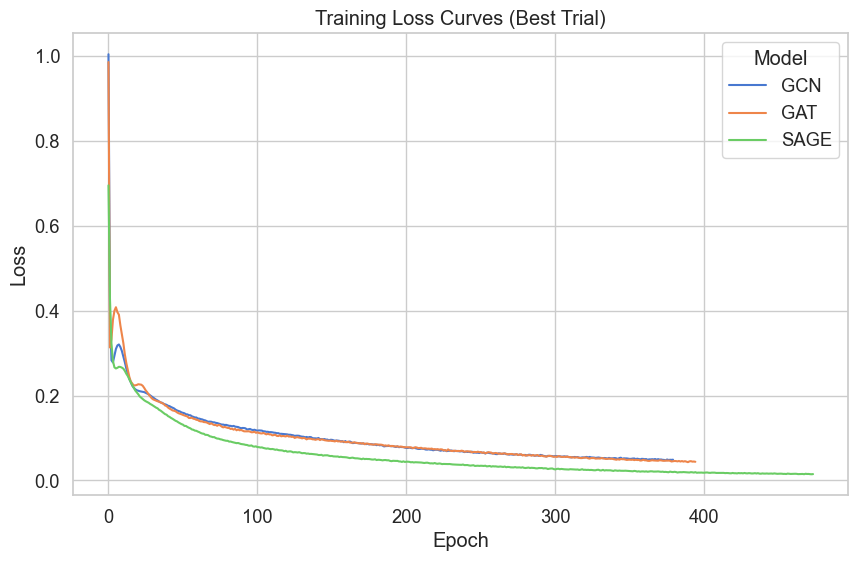

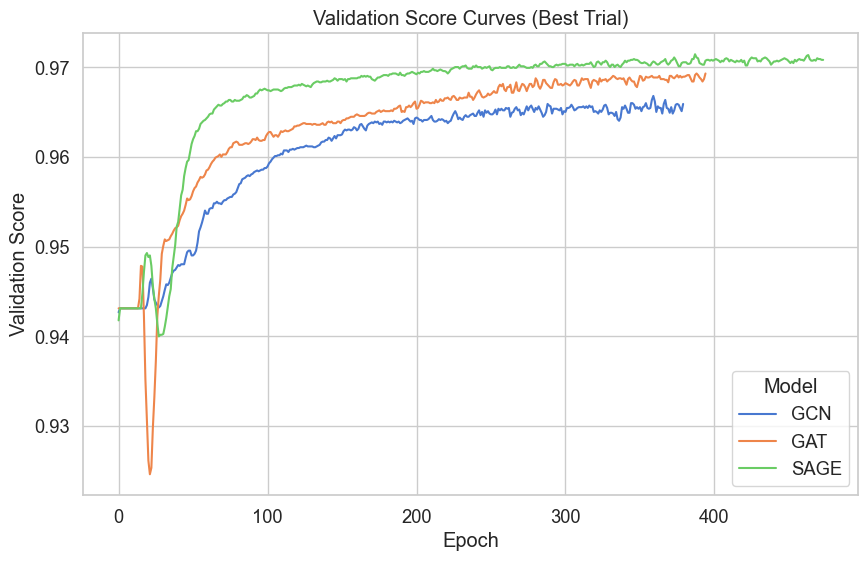

In [6]:
# === Plot 1: Training curves (best trial per model) ===
plt.figure(figsize=(10,6))
sns.lineplot(data=all_histories, x="epoch", y="train_loss", hue="Model")
plt.title("Training Loss Curves (Best Trial)")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.show()

plt.figure(figsize=(10,6))
sns.lineplot(data=all_histories, x="epoch", y="val_score", hue="Model")
plt.title("Validation Score Curves (Best Trial)")
plt.ylabel("Validation Score")
plt.xlabel("Epoch")
plt.show()

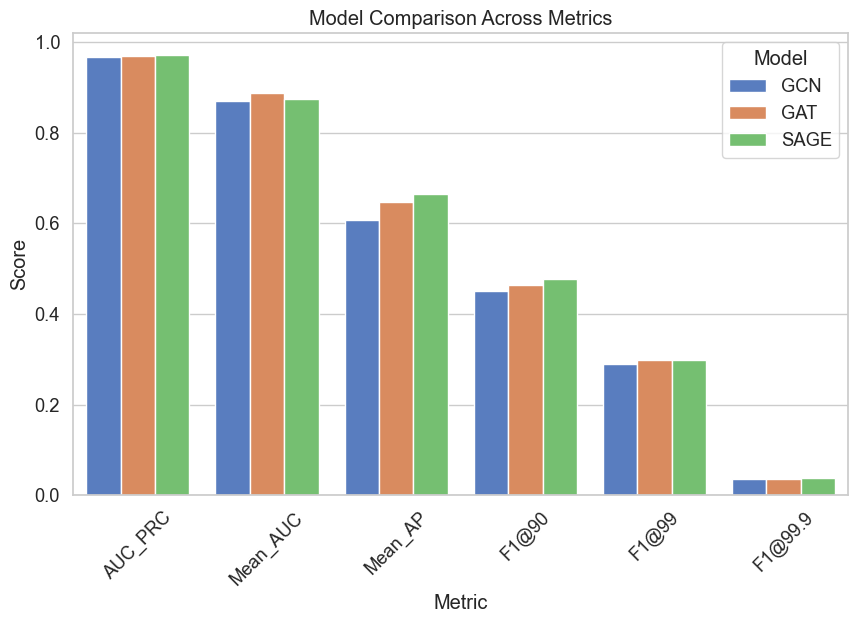

In [7]:
# === Plot 2: Summary barplots ===
plt.figure(figsize=(10,6))
summary_melt = summary_df.melt("Model", var_name="Metric", value_name="Score")
sns.barplot(data=summary_melt, x="Metric", y="Score", hue="Model")
plt.title("Model Comparison Across Metrics")
plt.xticks(rotation=45)
plt.show()


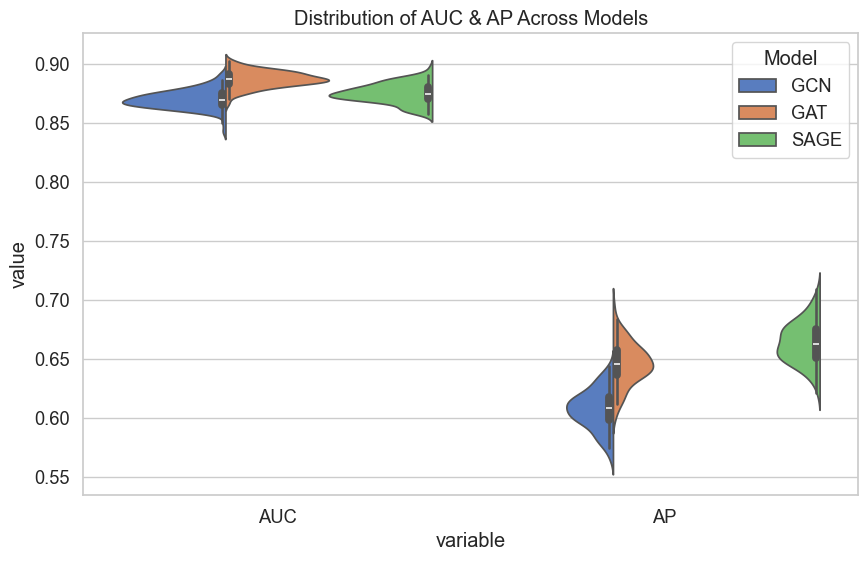

In [8]:
# === Plot 3: AUC & AP distributions ===
plt.figure(figsize=(10,6))
sns.violinplot(data=all_ti.melt(id_vars="Model"), x="variable", y="value", hue="Model", split=True)
plt.title("Distribution of AUC & AP Across Models")
plt.show()

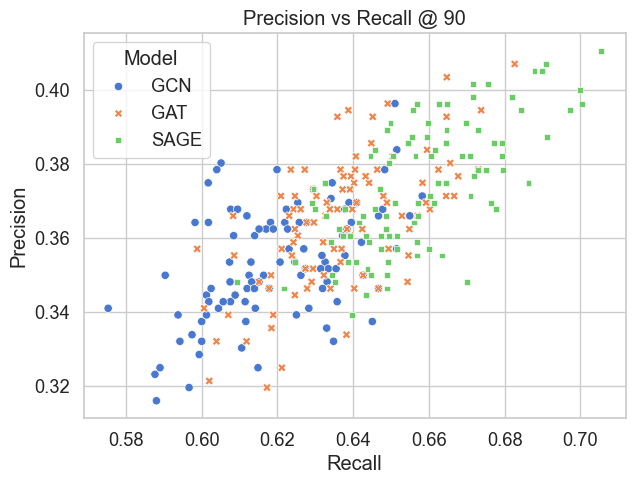

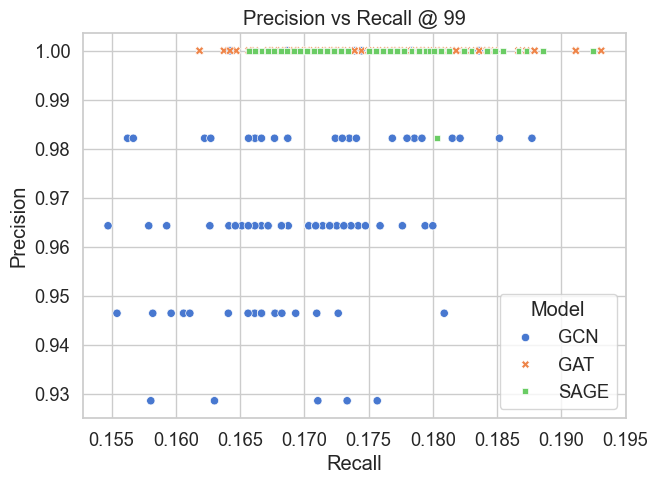

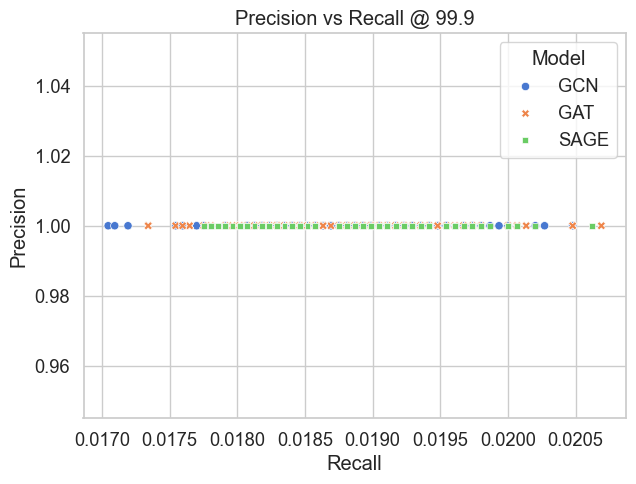

In [9]:
# === Plot 4: Precision vs Recall scatter (90, 99, 99.9) ===
for t in ["90", "99", "99.9"]:
    plt.figure(figsize=(7,5))
    sns.scatterplot(
        data=all_td,
        x=f"Recall_{t}", y=f"Precision_{t}",
        hue="Model", style="Model"
    )
    plt.title(f"Precision vs Recall @ {t}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.show()

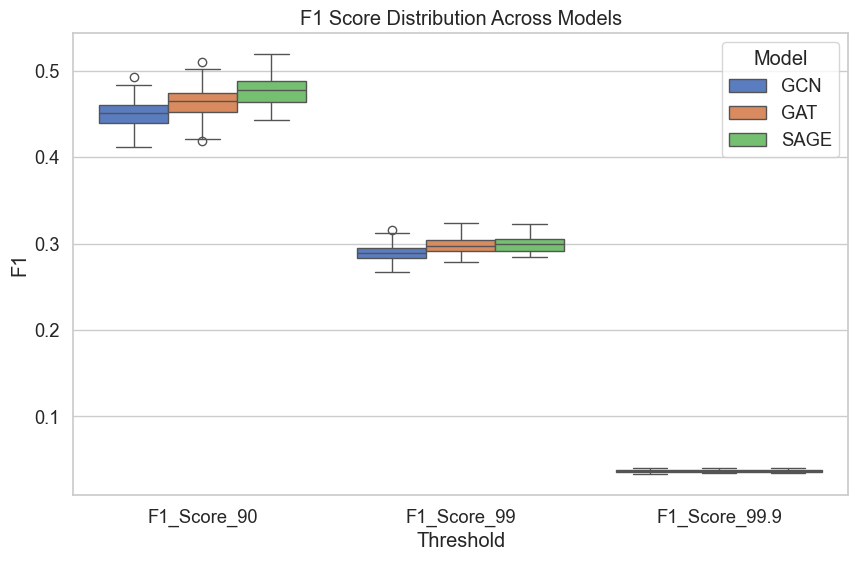

In [10]:
# === Plot 5: F1 score distributions ===
plt.figure(figsize=(10,6))
f1_cols = [c for c in all_td.columns if "F1_Score" in c]
f1_melt = all_td.melt(id_vars="Model", value_vars=f1_cols,
                      var_name="Threshold", value_name="F1")
sns.boxplot(data=f1_melt, x="Threshold", y="F1", hue="Model")
plt.title("F1 Score Distribution Across Models")
plt.show()

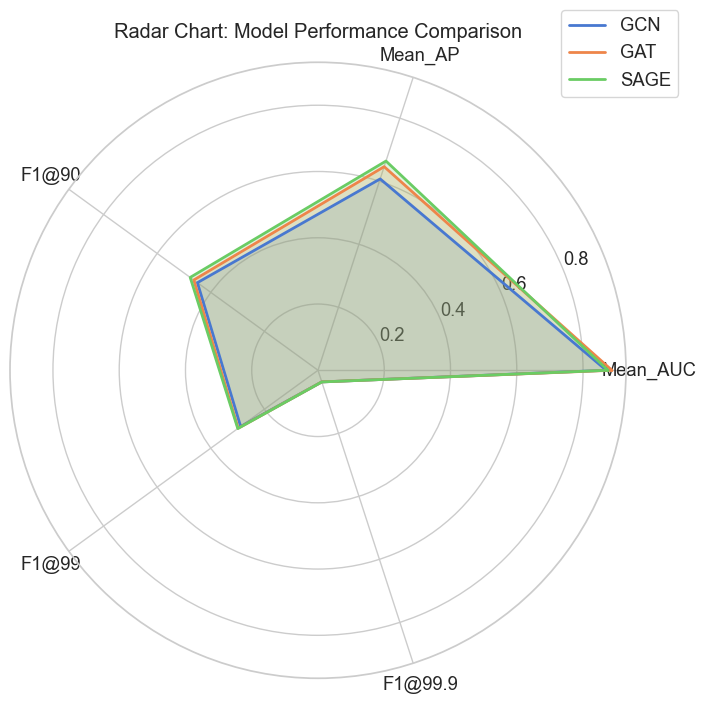

In [14]:
# === Plot 7: Radar chart (compare models on multiple metrics) ===

radar_metrics = ["Mean_AUC", "Mean_AP", "F1@90", "F1@99", "F1@99.9"]
labels = radar_metrics
num_vars = len(labels)

angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

plt.figure(figsize=(8,8))
ax = plt.subplot(111, polar=True)

for i, row in summary_df.iterrows():
    values = [row[m] for m in radar_metrics]
    values += values[:1]
    ax.plot(angles, values, label=row["Model"], linewidth=2)
    ax.fill(angles, values, alpha=0.2)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
plt.title("Radar Chart: Model Performance Comparison")
plt.legend(loc="upper right", bbox_to_anchor=(1.1, 1.1))
plt.show()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_26364\3597519837.py:19: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1}` instead.

  sns.barplot(data=melted[melted["Metric"].str.contains("_mean")],


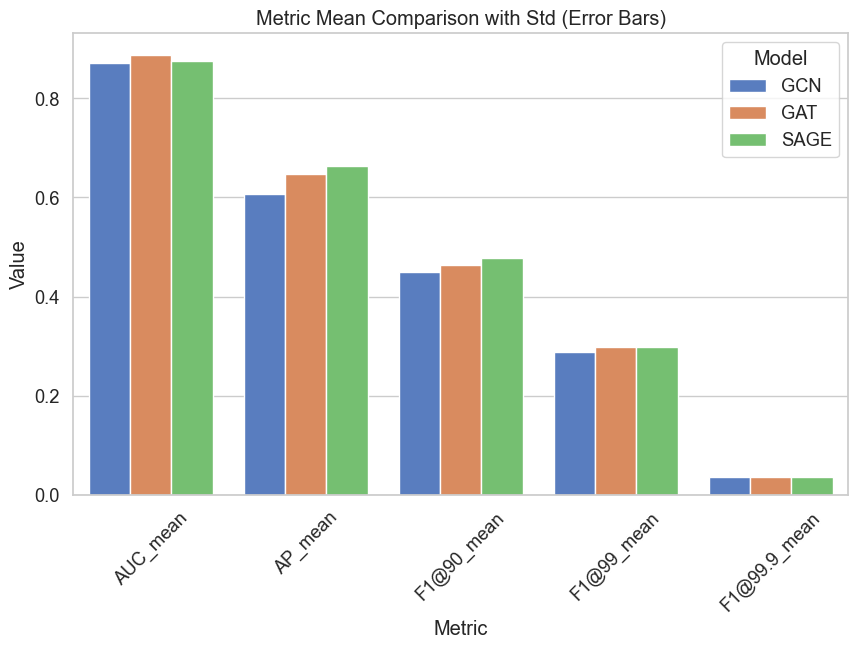

In [15]:
# === Plot 8: Metric stability (mean ± std) ===
stability = []
for model in models:
    td = pd.read_csv(os.path.join(BASE_DIR, model, "results_TD.csv"))
    ti = pd.read_csv(os.path.join(BASE_DIR, model, "results_TI.csv"))
    stability.append({
        "Model": model,
        "AUC_mean": ti["AUC"].mean(), "AUC_std": ti["AUC"].std(),
        "AP_mean": ti["AP"].mean(), "AP_std": ti["AP"].std(),
        "F1@90_mean": td["F1_Score_90"].mean(), "F1@90_std": td["F1_Score_90"].std(),
        "F1@99_mean": td["F1_Score_99"].mean(), "F1@99_std": td["F1_Score_99"].std(),
        "F1@99.9_mean": td["F1_Score_99.9"].mean(), "F1@99.9_std": td["F1_Score_99.9"].std(),
    })

stab_df = pd.DataFrame(stability)
melted = stab_df.melt(id_vars="Model", var_name="Metric", value_name="Value")

plt.figure(figsize=(10,6))
sns.barplot(data=melted[melted["Metric"].str.contains("_mean")], 
            x="Metric", y="Value", hue="Model", 
            capsize=.1, errwidth=1)
plt.xticks(rotation=45)
plt.title("Metric Mean Comparison with Std (Error Bars)")
plt.show()

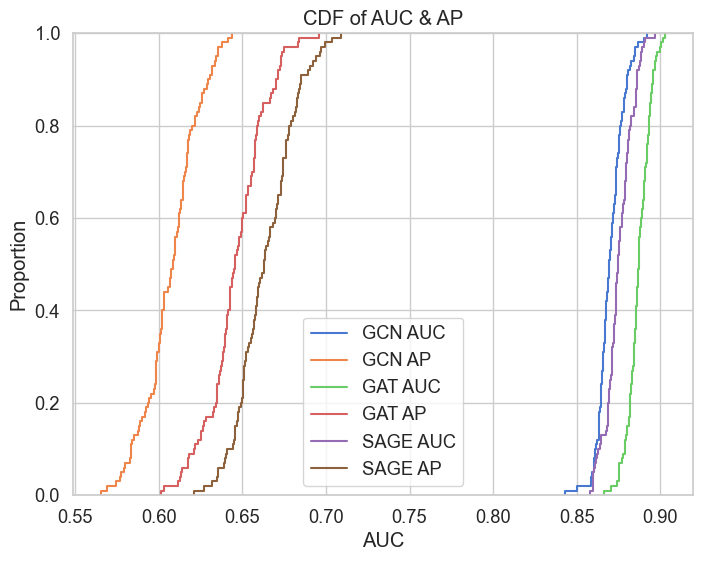

In [16]:
# === Plot 9: CDF of AUC & AP ===
plt.figure(figsize=(8,6))
for model in models:
    ti = all_ti[all_ti["Model"] == model]
    sns.ecdfplot(ti["AUC"], label=f"{model} AUC")
    sns.ecdfplot(ti["AP"], label=f"{model} AP")
plt.title("CDF of AUC & AP")
plt.legend()
plt.show()


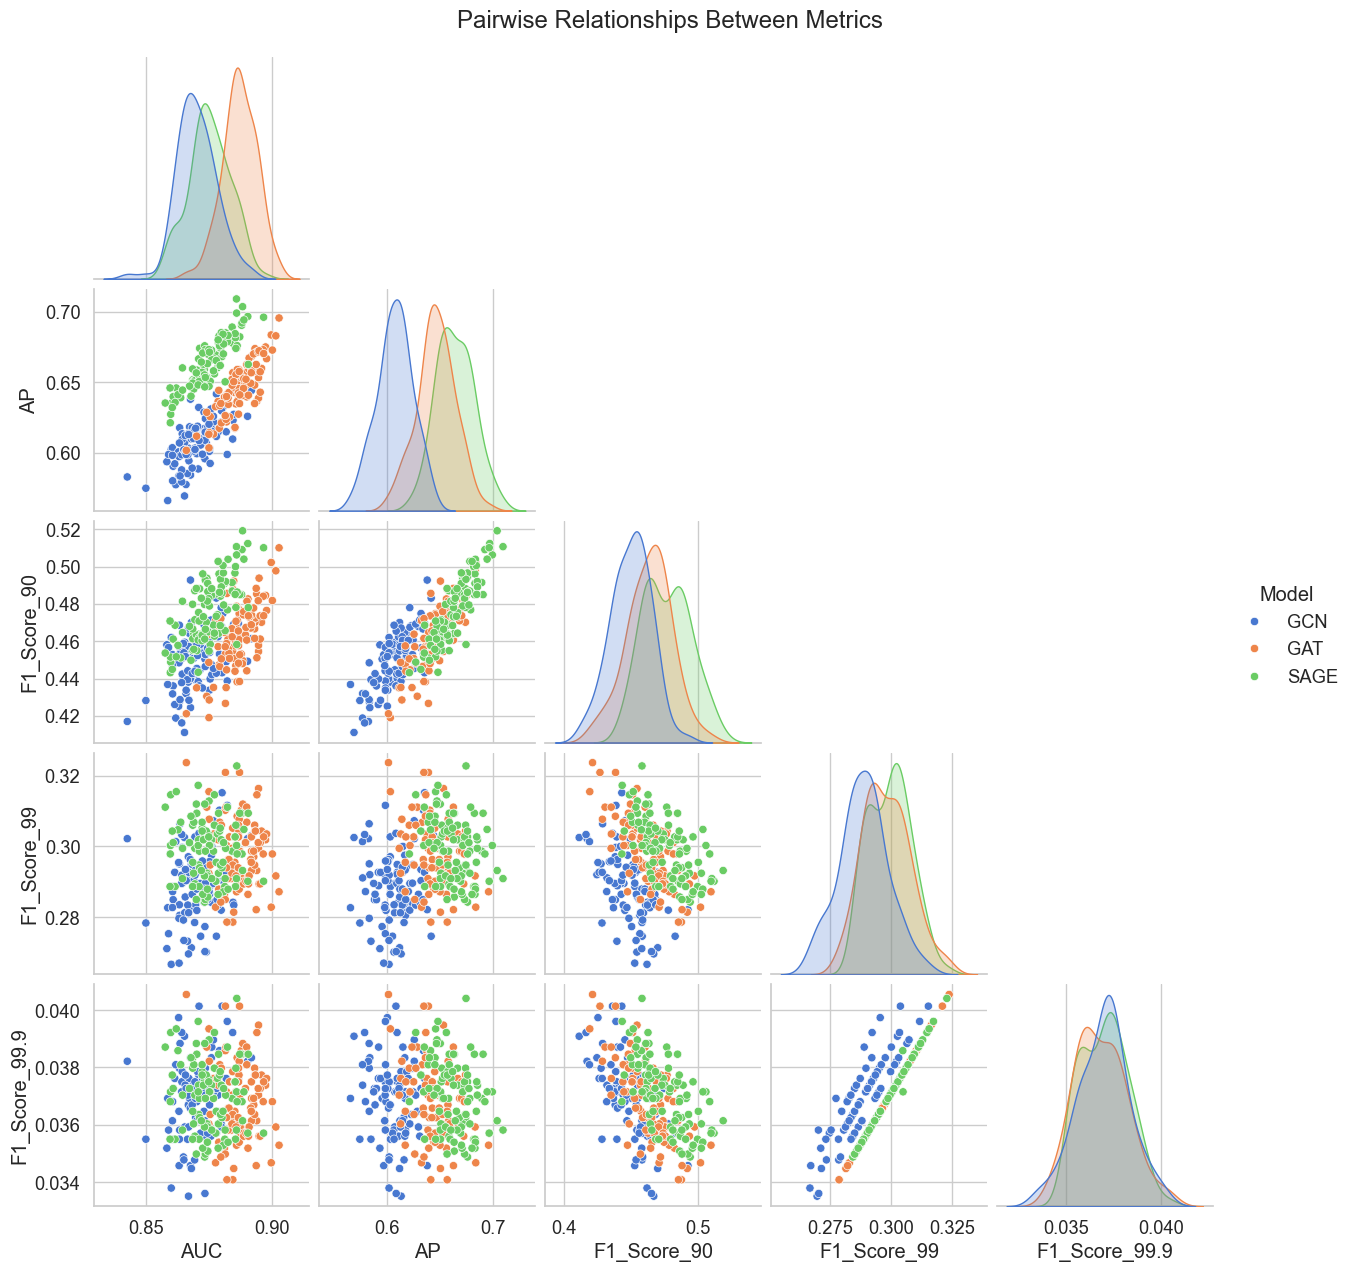

In [17]:
# === Plot 10: Pairplot of metrics ===
metrics_for_pair = ["AUC", "AP"]
f1_cols = [c for c in all_td.columns if "F1_Score" in c]
pair_df = pd.concat([all_ti[metrics_for_pair], all_td[f1_cols]], axis=1)
pair_df["Model"] = all_ti["Model"].values
sns.pairplot(pair_df, hue="Model", corner=True)
plt.suptitle("Pairwise Relationships Between Metrics", y=1.02)
plt.show()

In [ ]:
BASE_DIR = "results"
models = ["GCN", "GAT", "SAGE"]

all_trials = []

for model in models:
    with open(os.path.join(BASE_DIR, model, f"{model}_training_results.json")) as f:
        results = json.load(f)
    study = pd.DataFrame(results["Study"])
    study["Model"] = model
    study["Trial"] = study["number"]
    study["LearningRate"] = study["params_lr"]
    study["Performance"] = study["value"]
    all_trials.append(study)

all_trials = pd.concat(all_trials, ignore_index=True)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_26364\4030578163.py:3: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(data=all_trials, x="Model", y="Performance", inner="quartile", scale="width")


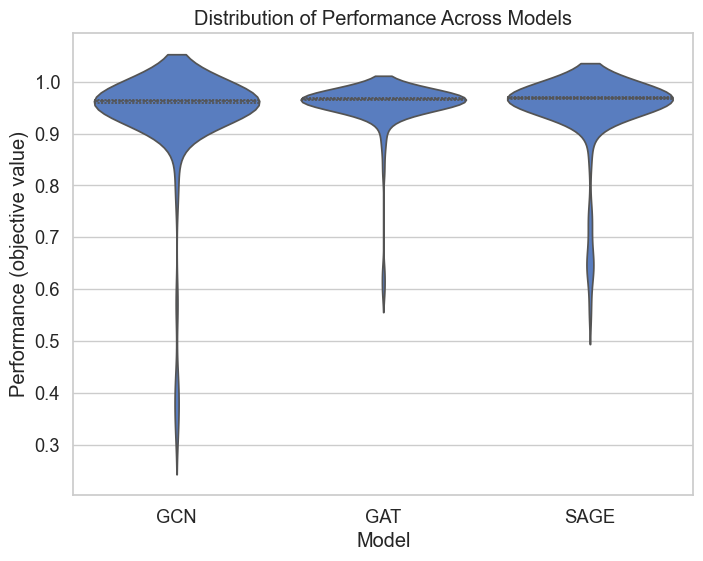

In [29]:
# === Plot 1: Trial Performance distributions ===
plt.figure(figsize=(8,6))
sns.violinplot(data=all_trials, x="Model", y="Performance", inner="quartile", scale="width")
plt.title("Distribution of Performance Across Models")
plt.ylabel("Performance (objective value)")
plt.show()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_26364\2122390611.py:3: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(data=all_trials, x="Model", y="LearningRate", inner="point", scale="width")


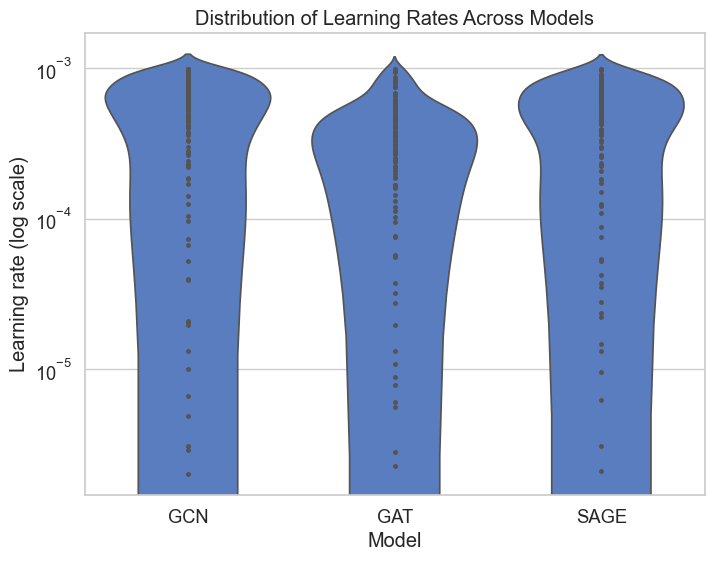

In [30]:
# === Plot 2: Learning Rate distributions ===
plt.figure(figsize=(8,6))
sns.violinplot(data=all_trials, x="Model", y="LearningRate", inner="point", scale="width")
plt.yscale("log")
plt.title("Distribution of Learning Rates Across Models")
plt.ylabel("Learning rate (log scale)")
plt.show()

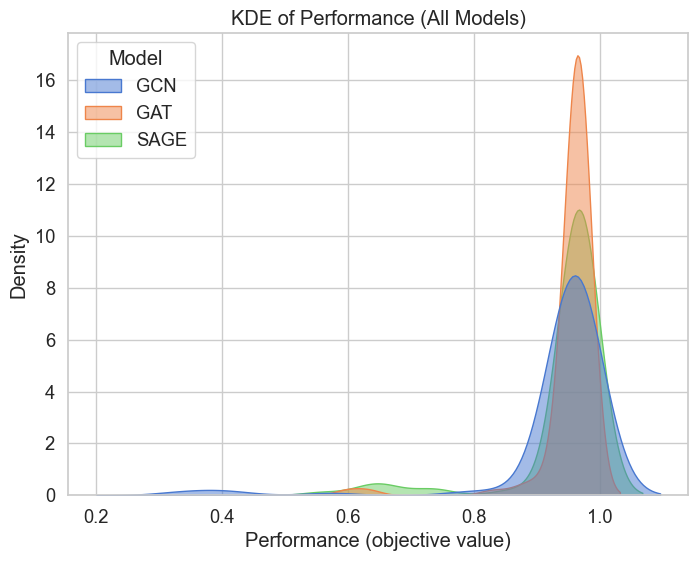

In [31]:
# === Plot 3: KDE overlay of Performance ===
plt.figure(figsize=(8,6))
sns.kdeplot(data=all_trials, x="Performance", hue="Model", fill=True, common_norm=False, alpha=0.5)
plt.title("KDE of Performance (All Models)")
plt.xlabel("Performance (objective value)")
plt.show()

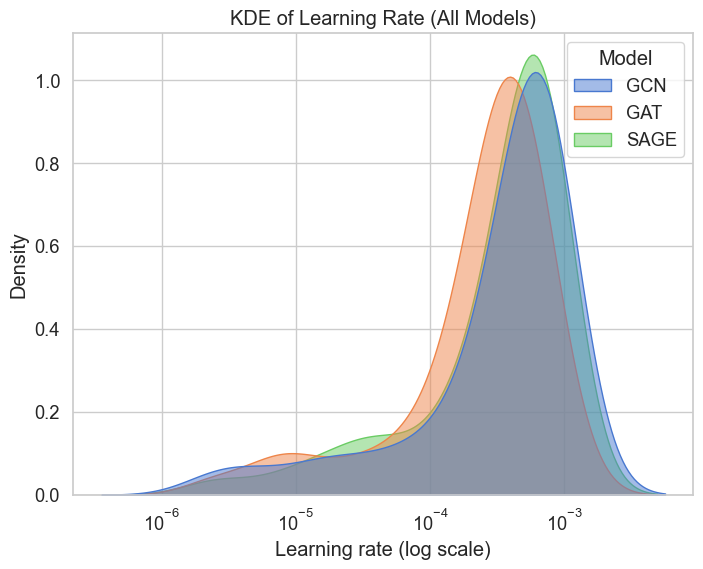

In [32]:
# === Plot 4: KDE overlay of Learning Rate ===
plt.figure(figsize=(8,6))
sns.kdeplot(data=all_trials, x="LearningRate", hue="Model", fill=True, common_norm=False, alpha=0.5, log_scale=True)
plt.title("KDE of Learning Rate (All Models)")
plt.xlabel("Learning rate (log scale)")
plt.show()

In [35]:
BASE_DIR = "results"
models = ["GCN", "GAT", "SAGE"]

all_scores = []

for model in models:
    tl_file = os.path.join(BASE_DIR, model, "results_TI.csv")
    if os.path.exists(tl_file):
        df = pd.read_csv(tl_file)
        df["Model"] = model
        all_scores.append(df)

all_scores = pd.concat(all_scores, ignore_index=True)

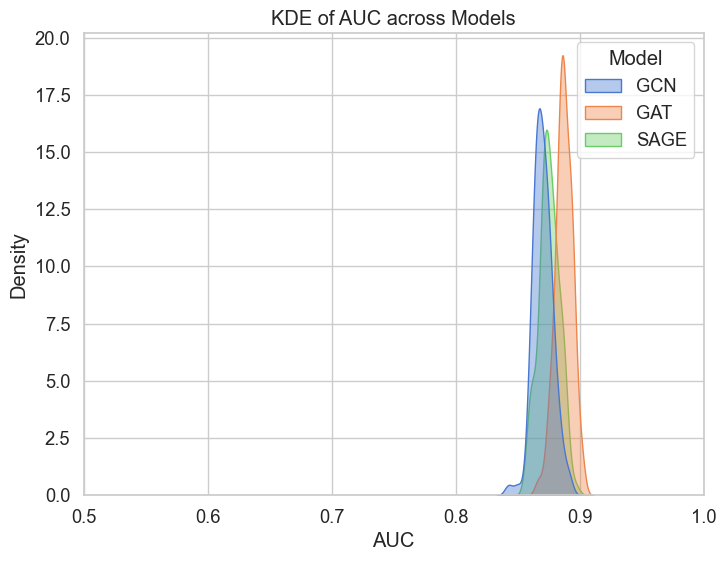

In [36]:
# === KDE of AUC ===
plt.figure(figsize=(8,6))
sns.kdeplot(data=all_scores, x="AUC", hue="Model", fill=True, alpha=0.4)
plt.title("KDE of AUC across Models")
plt.xlabel("AUC")
plt.xlim(0.5, 1.0)  # adjust if needed
plt.show()

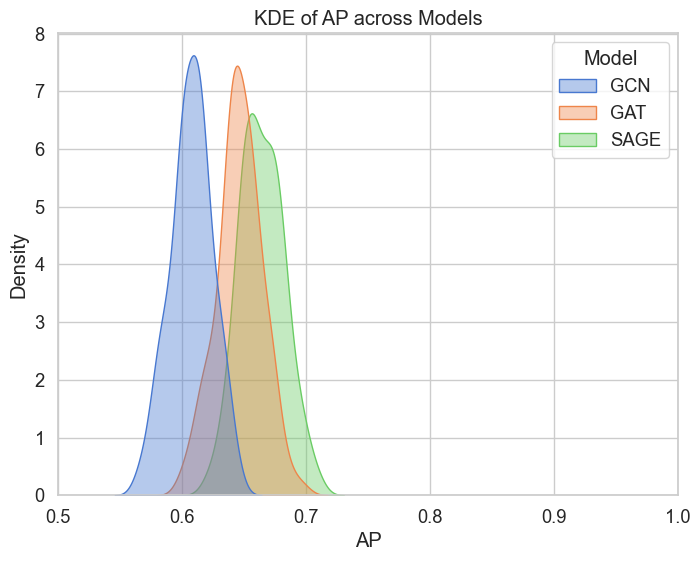

In [37]:
# === KDE of AP ===
plt.figure(figsize=(8,6))
sns.kdeplot(data=all_scores, x="AP", hue="Model", fill=True, alpha=0.4)
plt.title("KDE of AP across Models")
plt.xlabel("AP")
plt.xlim(0.5, 1.0)  # adjust if needed
plt.show()

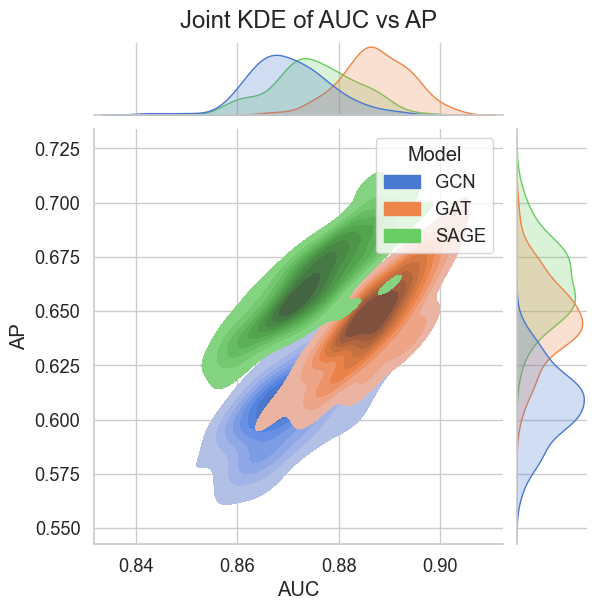

In [38]:
# === Jointplot AUC vs AP (bonus) ===
sns.jointplot(data=all_scores, x="AUC", y="AP", hue="Model", kind="kde", fill=True, height=6)
plt.suptitle("Joint KDE of AUC vs AP", y=1.02)
plt.show()